# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Pranavi B  
**Course:** Your Course Title  
**Lab Assignment:** Lab 3 – Clustering Analysis Using K-Means and K-Medoids Algorithms

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

wine = load_wine()

X = wine.data
y = wine.target

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])
print("Number of Samples:", X.shape[0])

Dataset Shape: (178, 13)
Number of Features: 13
Number of Samples: 178


In [2]:
print("Feature Names:")
for feature in wine.feature_names:
    print(feature)

Feature Names:
alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


In [3]:
wine_df = pd.DataFrame(X, columns=wine.feature_names)

print("First 10 Rows:")
display(wine_df.head(10))

print("\nDataset Information:")
print(wine_df.info())

First 10 Rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64

In [4]:
print("Class Distribution:")

class_distribution = pd.Series(y).value_counts().sort_index()

print(class_distribution)

print("\nClass Names:")
for i, name in enumerate(wine.target_names):
    print(i, "=", name)

Class Distribution:
0    59
1    71
2    48
Name: count, dtype: int64

Class Names:
0 = class_0
1 = class_1
2 = class_2


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardized Dataset Shape:", X_scaled.shape)

print("\nFirst 5 Standardized Rows:")
print(X_scaled[:5])

Standardized Dataset Shape: (178, 13)

First 5 Standardized Rows:
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


In [6]:
print("Means after standardization:")
print(np.mean(X_scaled, axis=0))

print("\nStandard deviations after standardization:")
print(np.std(X_scaled, axis=0))

Means after standardization:
[ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17 -1.95536471e-16  9.44313292e-16 -4.17892936e-16
 -1.54059038e-15 -4.12903170e-16  1.39838203e-15  2.12688793e-15
 -6.98567296e-17]

Standard deviations after standardization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [9]:
kmeans_labels = kmeans.labels_

print("K-Means Cluster Labels:")
print(kmeans_labels)

K-Means Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [10]:
print("K-Means Cluster Centers:")
print(kmeans.cluster_centers_)

K-Means Cluster Centers:
[[-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]]


In [11]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score:")
print(kmeans_silhouette)

K-Means Silhouette Score:
0.2848589191898987


In [12]:
kmeans_ari = adjusted_rand_score(
    y,
    kmeans_labels
)

print("K-Means Adjusted Rand Index (ARI):")
print(kmeans_ari)

K-Means Adjusted Rand Index (ARI):
0.8974949815093207


In [13]:
print("K-MEANS RESULTS")
print("-------------------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", kmeans_silhouette)
print("Adjusted Rand Index (ARI):", kmeans_ari)

K-MEANS RESULTS
-------------------------
Number of Clusters: 3
Silhouette Score: 0.2848589191898987
Adjusted Rand Index (ARI): 0.8974949815093207


In [14]:
from sklearn_extra.cluster import KMedoids

In [15]:
kmedoids = KMedoids(
    n_clusters=3,
    random_state=42,
    metric="euclidean"
)

kmedoids.fit(X_scaled)

KMedoids(n_clusters=3, random_state=42)

In [16]:
kmedoids_labels = kmedoids.labels_

print("K-Medoids Cluster Labels:")
print(kmedoids_labels)

K-Medoids Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 1 2 1 1 1 2 1 2 1 2
 2 1 1 1 1 2 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 2 0 1 2 1 1 1 1 1 1 1 1 1 1 2 2
 1 1 1 1 1 1 1 1 1 2 2 0 1 2 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [17]:
print("K-Medoids Medoid Indices:")
print(kmedoids.medoid_indices_)

print("\nK-Medoids Medoids:")
print(kmedoids.cluster_centers_)

K-Medoids Medoid Indices:
[174 106  35]

K-Medoids Medoids:
[[ 4.93342620e-01  1.41260912e+00  4.14819587e-01  1.05251577e+00
   1.58571702e-01 -7.93334154e-01 -1.28434417e+00  5.49107795e-01
  -3.16950051e-01  9.69783022e-01 -1.12951789e+00 -1.48544548e+00
   9.89339909e-03]
 [-9.27212090e-01 -5.44296535e-01 -9.01103141e-01 -1.48624201e-01
  -1.38612179e+00 -1.03368389e+00  7.33234123e-04  6.56394314e-02
   6.85084581e-02 -7.17239912e-01  1.86683727e-01  7.88587455e-01
  -7.54385098e-01]
 [ 5.92163817e-01 -4.72483484e-01  1.58945723e-01  3.01803287e-01
   1.81450206e-02  6.48764240e-01  9.54501620e-01 -8.20719236e-01
   4.71487808e-01  1.81290590e-02  3.62177276e-01  1.21232030e+00
   5.51257335e-01]]


In [18]:
kmedoids_silhouette = silhouette_score(
    X_scaled,
    kmedoids_labels
)

print("K-Medoids Silhouette Score:")
print(kmedoids_silhouette)

K-Medoids Silhouette Score:
0.26597740204536796


In [19]:
kmedoids_ari = adjusted_rand_score(
    y,
    kmedoids_labels
)

print("K-Medoids Adjusted Rand Index (ARI):")
print(kmedoids_ari)

K-Medoids Adjusted Rand Index (ARI):
0.7263406645756675


In [20]:
print("K-MEDOIDS RESULTS")
print("-------------------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", kmedoids_silhouette)
print("Adjusted Rand Index (ARI):", kmedoids_ari)

K-MEDOIDS RESULTS
-------------------------
Number of Clusters: 3
Silhouette Score: 0.26597740204536796
Adjusted Rand Index (ARI): 0.7263406645756675


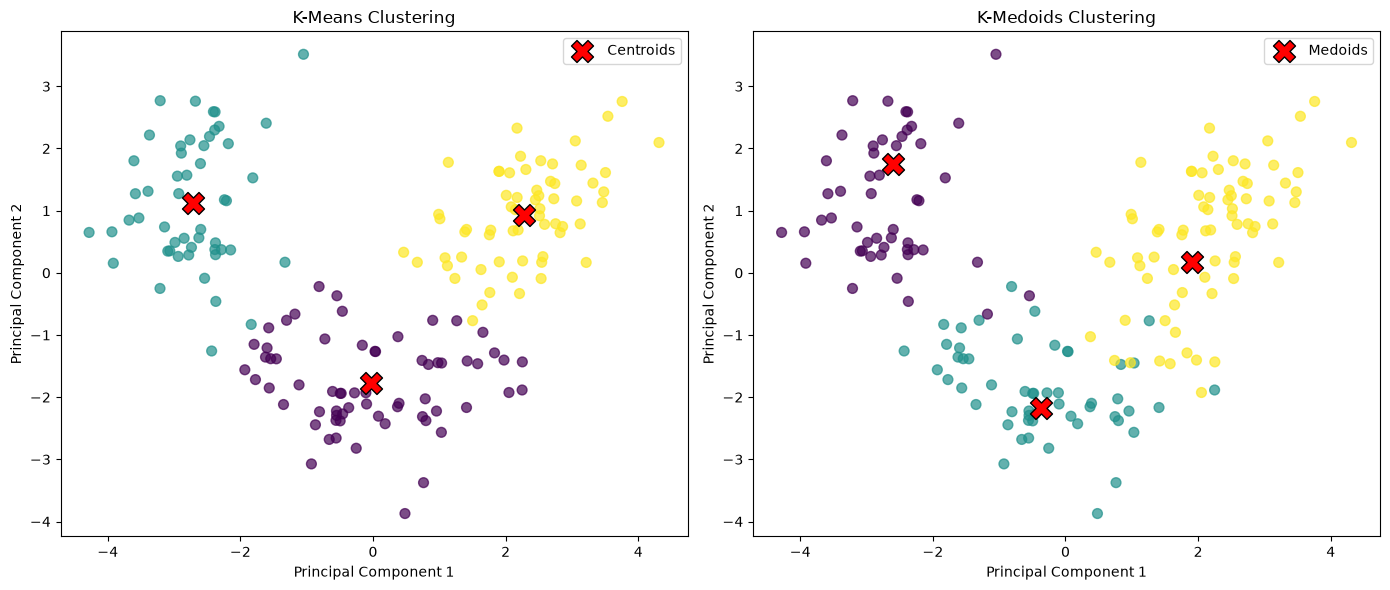

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce the scaled data to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform K-Means cluster centers into PCA space
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)

# Transform K-Medoids centers into PCA space
kmedoids_centers_pca = pca.transform(kmedoids.cluster_centers_)

# Create side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------
# K-Means Plot
# -------------------------
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=50,
    alpha=0.7
)

axes[0].scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolor="black",
    label="Centroids"
)

axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

# -------------------------
# K-Medoids Plot
# -------------------------
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmedoids_labels,
    cmap="viridis",
    s=50,
    alpha=0.7
)

axes[1].scatter(
    kmedoids_centers_pca[:, 0],
    kmedoids_centers_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolor="black",
    label="Medoids"
)

axes[1].set_title("K-Medoids Clustering")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 4: Visualization and Comparison

The two clustering algorithms were visualized using Principal Component Analysis (PCA) to reduce the scaled dataset to two dimensions. The K-Means plot displays the cluster centroids, while the K-Medoids plot displays the medoids. The visualizations provide a direct comparison of how the observations are grouped and how the central points are positioned.

The K-Means model produced a Silhouette Score of 0.2849 and an Adjusted Rand Index (ARI) of 0.8975. The K-Medoids model produced a Silhouette Score of 0.2660 and an ARI of 0.7263. Therefore, for this dataset and the selected three-cluster configuration, K-Means produced higher values for both evaluation metrics. The visualizations also show differences in the positioning of the cluster centers and the allocation of observations between the two methods.

K-Means identifies cluster centers by calculating the mean position of observations assigned to each cluster. As a result, it is particularly useful when clusters are relatively compact and the mean provides a meaningful representation of the group. K-Medoids instead selects actual observations from the dataset as representative points, making it less sensitive to extreme observations and potentially useful when robustness to outliers is important.

Based on the results of this experiment, K-Means provided stronger agreement with the known class labels and a slightly higher degree of cluster separation according to the Silhouette Score. K-Medoids produced somewhat different cluster assignments because its representative points are actual observations rather than calculated means. The choice between the two algorithms should therefore depend on the characteristics of the dataset, the presence of outliers, and whether representative cluster centers need to correspond to actual observations.